# 05 Hauptexperiment: sechs Embedder und BM25 auf GermanQuAD

## Ziel und Forschungsfrage
Dieses Notebook dokumentiert das Hauptexperiment der Arbeit. Es vergleicht sechs Embedding-Modelle (Dense Retrieval) mit einer BM25-Baseline auf dem Testsplit von GermanQuAD-Retrieval. Die Forschungsfrage lautet: Welche der Embedding-Modelle liefern im deutschsprachigen Retrieval eine bessere Rangordnung als BM25, und wie unterscheiden sich die Modelle untereinander?

Die Läufe selbst liefen über Skripte (`embed_eval.py`, `scripts/run_bm25.py`, `compare_models.py`, `make_results.py`). Das Notebook fasst Versuchsaufbau und Befehle zusammen, lädt die persistierten Ergebnisse aus `code/output/harness/`, zeigt sie an und prüft sie auf Konsistenz. Verbindliche Methode: `docs/evaluation_protocol.md`.

## Versuchsaufbau
- **Datensatz:** `mteb/germanquad-retrieval` (Revision `9af36714ebd9bba5235c4b9862779adaddbfae52`; corpus, queries) und `mteb/germanquad-retrieval-qrels` (Revision `ed232776ce5d736028c1da18e81ab7048969f369`; Split test), normalisiert in `code/output/germanquad/` (2.204 Fragen, 474 Passagen, je Frage eine relevante Passage). Retrieval auf Dokumentebene, Cosine-Similarity, keine Generierung, kein Query-Rewriting.
- **Retriever:** BM25 (`rank_bm25`, k1 = 1,5, b = 0,75) sowie sechs Embedder aus der Registry `pylib/embedders.py`: multilingual-e5-large, bge-m3, gte-multilingual-base, jina-embeddings-v3, text-embedding-3-small, text-embedding-3-large.
- **Eingabelänge:** Hauptanalyse mit nativer maximaler Sequenzlänge je Modell. Sensitivität (nur explorativ): bge-m3, gte-multilingual-base und jina-v3 zusätzlich mit `max_seq_length = 512`; e5-large ist bereits auf 512 begrenzt, OpenAI-Modelle entfallen.
- **Metriken:** Recall@k, Success@k, MRR@k, Precision@k für k = 1, 5, 10. Primärmetrik ist MRR@10.
- **Signifikanz:** gepaarter Vorzeichenwechsel-Randomisierungstest auf Cluster-Ebene (Cluster = Gold-Passage), zweiseitig, B = 100.000, Seed 42 (exakt bei n≠0 <= 16); 95-%-Cluster-Bootstrap-CI (B = 10.000); Holm-Korrektur, alpha = 0,05. Konfirmatorische Familie: jeder Embedder gegen BM25 auf MRR@10 (6 Tests). Embedder-Paare und sekundäre Metriken sind explorativ. McNemar (exakt) nur deskriptiv.
- **Deckeneffekt-Schwelle:** n≠0 < 20 (Cluster mit Differenz ungleich 0), bei Success@k analog b + c < 20, gilt als "nicht aussagekräftig".

## Konfiguration und Stil

In [1]:
import json, os, subprocess, sys, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

CODE = Path.cwd() if (Path.cwd() / "embed_eval.py").exists() else Path.cwd() / "code"
HARNESS = CODE / "output" / "harness"
sys.path.insert(0, str(CODE))
sys.path.insert(0, str(CODE / "pylib"))
import compare_models as cm
from local_dataset_io import load_jsonl
from retrieval_metrics import build_gold
from significance import holm

RUN_EXPERIMENTS = False  # True: Läufe neu ausführen (Modell-Downloads, Rechenzeit; überschreibt output/harness)

MODELS = {"e5-large": "multilingual-e5-large", "bge-m3": "bge-m3", "gte-multilingual-base": "gte-multilingual-base",
          "jina-v3": "jina-embeddings-v3", "openai-3-small": "text-embedding-3-small",
          "openai-3-large": "text-embedding-3-large"}
LABEL = {"bm25": "BM25", **MODELS}
LEN512 = ["bge-m3", "gte-multilingual-base", "jina-v3"]

plt.rcParams.update({"figure.figsize": (7, 4), "font.size": 10, "axes.titlesize": 11, "axes.grid": True, "grid.alpha": 0.3})
pd.options.display.float_format = "{:.4f}".format
print("code dir:", CODE)

Matplotlib is building the font cache; this may take a moment.


code dir: <PROJEKT>/code


## Schritt 1: Läufe
Mit `RUN_EXPERIMENTS = True` führt die Zelle die Befehlszeilen der Reihe nach aus: `embed_eval.py` je Modell (nativ) und je drei Modelle mit `--max-seq-length 512`, BM25 (`scripts/run_bm25.py`), danach `compare_models.py` und `make_results.py --recompute`. Die OpenAI-Modelle laufen nur, wenn `EMBED_OPENAI_API_KEY` gesetzt ist; sonst werden sie übersprungen. Voraussetzung sind die Pakete aus `requirements-embed.txt`. Der Standardwert `False` lädt nur die vorhandenen Ergebnisse (Schritt 2). Die Laufzeit auf CPU liegt im Bereich von Stunden (e5-large: rund 465 s Encodierung).

In [2]:
def build_commands() -> list[tuple[str, list[str]]]:
    py, ds = sys.executable, "output/germanquad"
    ee = [py, str(CODE / "embed_eval.py"), "--dataset-dir", ds]
    cmds = []
    for m in MODELS:
        if m.startswith("openai") and not os.environ.get("EMBED_OPENAI_API_KEY"):
            print(f"übersprungen (EMBED_OPENAI_API_KEY fehlt): {m}")
            continue
        cmds.append((m, ee + ["--model", m]))
    cmds += [(f"{m} (512)", ee + ["--model", m, "--max-seq-length", "512"]) for m in LEN512]
    cmds.append(("bm25", [py, str(CODE / "scripts" / "run_bm25.py")]))
    cmds.append(("compare", [py, str(CODE / "compare_models.py")]))
    cmds.append(("make_results", [py, str(CODE / "make_results.py"), "--recompute"]))
    return cmds

cmds = build_commands()
if RUN_EXPERIMENTS:
    for name, cmd in cmds:
        t0 = time.time()
        subprocess.run(cmd, check=True, cwd=CODE)
        print(f"{name}: fertig in {time.time() - t0:.0f} s")
else:
    print("RUN_EXPERIMENTS = False: es werden nur die persistierten Ergebnisse geladen. Befehle:")
    for name, cmd in cmds:
        print(" ", " ".join(["python"] + [Path(c).name if c.endswith(".py") else c for c in cmd[1:]]))

RUN_EXPERIMENTS = False: es werden nur die persistierten Ergebnisse geladen. Befehle:
  python embed_eval.py --dataset-dir output/germanquad --model e5-large
  python embed_eval.py --dataset-dir output/germanquad --model bge-m3
  python embed_eval.py --dataset-dir output/germanquad --model gte-multilingual-base
  python embed_eval.py --dataset-dir output/germanquad --model jina-v3
  python embed_eval.py --dataset-dir output/germanquad --model openai-3-small
  python embed_eval.py --dataset-dir output/germanquad --model openai-3-large
  python embed_eval.py --dataset-dir output/germanquad --model bge-m3 --max-seq-length 512
  python embed_eval.py --dataset-dir output/germanquad --model gte-multilingual-base --max-seq-length 512
  python embed_eval.py --dataset-dir output/germanquad --model jina-v3 --max-seq-length 512
  python run_bm25.py
  python compare_models.py
  python make_results.py --recompute


## Schritt 2: Ergebnisse laden

In [2]:
NATIVE = {m: json.loads((HARNESS / m / "metrics_germanquad.json").read_text()) for m in MODELS}
S512 = {m: json.loads((HARNESS / f"{m}__len512" / "metrics_germanquad.json").read_text()) for m in LEN512}
CMP = json.loads((HARNESS / "comparison_germanquad.json").read_text())
TESTS = pd.DataFrame(CMP["tests"])

queries, docs, qrels = (load_jsonl(CODE / "output" / "germanquad" / f"{x}.normalized.jsonl") for x in ("queries", "docs", "qrels"))
qids = [str(q["query_id"]) for q in queries]
gold = build_gold(qrels, {str(d["doc_id"]) for d in docs}, 1)
clusters = [sorted(gold[q])[0] for q in qids]
RANKS = {m: cm.load_ranks(HARNESS / m / "per_query_germanquad.csv", qids) for m in MODELS}
RANKS["bm25"] = cm.load_ranks(CODE / "output" / "bm25_v2" / "per_query_ranks.csv", qids)
R512 = {m: cm.load_ranks(HARNESS / f"{m}__len512" / "per_query_germanquad.csv", qids) for m in LEN512}
print(f"{len(qids)} Queries, {len(set(clusters))} Cluster, {len(docs)} Passagen")

2204 Queries, 474 Cluster, 474 Passagen


### Tabelle 2: Retrievalqualität (native Eingabelänge)

In [4]:
def metrics_of(r):
    return {"MRR@10": cm.rr10(r).mean(), "Success@1": cm.succ(r, 1).mean(),
            "Success@5": cm.succ(r, 5).mean(), "Success@10": cm.succ(r, 10).mean()}

t3 = pd.DataFrame({LABEL[m]: metrics_of(RANKS[m]) for m in ["bm25", *MODELS]}).T
display(t3)

,MRR@10,Success@1,Success@5,Success@10
BM25,0.8844,0.8376,0.9483,0.9646
multilingual-e5-large,0.9333,0.8984,0.9791,0.9868
bge-m3,0.9456,0.9170,0.9805,0.9887
gte-multilingual-base,0.8859,0.8339,0.9519,0.9673
jina-embeddings-v3,0.9429,0.9074,0.9864,0.9918
text-embedding-3-small,0.9168,0.8730,0.9741,0.9823
text-embedding-3-large,0.9443,0.9083,0.9896,0.9936


### Tabelle 3: Konfirmatorische Tests (Embedder gegen BM25, MRR@10, Holm über 6 Tests)

In [5]:
conf = TESTS[TESTS.family.str.startswith("confirmatory")].copy()
t4 = pd.DataFrame({"Vergleich": conf.b.map(LABEL) + " - BM25", "Differenz": conf.diff_b_minus_a,
                   "CI95 unten": conf.ci95_cluster_bootstrap.str[0], "CI95 oben": conf.ci95_cluster_bootstrap.str[1],
                   "p roh": conf.p_cluster_signflip, "p Holm": conf.p_holm, "n≠0": conf.n_nonzero_clusters,
                   "p ist Schranke": conf.p_is_upper_bound, "nicht aussagekräftig": conf.not_informative})
display(t4.style.format({"p roh": "{:.2e}", "p Holm": "{:.2e}"}, precision=4).hide(axis="index"))

Vergleich,Differenz,CI95 unten,CI95 oben,p roh,p Holm,n≠0,p ist Schranke,nicht aussagekräftig
multilingual-e5-large - BM25,0.0488,0.0324,0.0664,1.00e-05,6.00e-05,230,True,False
bge-m3 - BM25,0.0611,0.0464,0.0767,1.00e-05,6.00e-05,224,True,False
gte-multilingual-base - BM25,0.0015,-0.0185,0.0223,8.84e-01,8.84e-01,249,False,False
jina-embeddings-v3 - BM25,0.0584,0.0427,0.0751,1.00e-05,6.00e-05,234,True,False
text-embedding-3-small - BM25,0.0324,0.0144,0.0507,2.90e-04,5.80e-04,255,False,False
text-embedding-3-large - BM25,0.0599,0.0433,0.0770,1.00e-05,6.00e-05,231,True,False


### Explorative Paarvergleiche der Embedder (MRR@10, Holm innerhalb der Familie)

In [6]:
pairs = TESTS[TESTS.family == "explorative: embedder pairs, MRR@10"]
tp = pd.DataFrame({"Vergleich": pairs.b.map(LABEL) + " - " + pairs.a.map(LABEL), "Differenz": pairs.diff_b_minus_a,
                   "CI95 unten": pairs.ci95_cluster_bootstrap.str[0], "CI95 oben": pairs.ci95_cluster_bootstrap.str[1],
                   "p roh": pairs.p_cluster_signflip, "p Holm": pairs.p_holm, "n≠0": pairs.n_nonzero_clusters})
display(tp.style.format({"p roh": "{:.2e}", "p Holm": "{:.2e}"}, precision=4).hide(axis="index"))

Vergleich,Differenz,CI95 unten,CI95 oben,p roh,p Holm,n≠0
bge-m3 - multilingual-e5-large,0.0123,0.0040,0.0207,4.78e-03,2.87e-02,126
gte-multilingual-base - multilingual-e5-large,-0.0473,-0.0604,-0.0348,1.00e-05,1.50e-04,164
jina-embeddings-v3 - multilingual-e5-large,0.0096,0.0002,0.0193,5.32e-02,2.66e-01,133
text-embedding-3-small - multilingual-e5-large,-0.0164,-0.0277,-0.0055,2.93e-03,2.05e-02,142
text-embedding-3-large - multilingual-e5-large,0.0110,0.0001,0.0224,5.73e-02,2.66e-01,133
gte-multilingual-base - bge-m3,-0.0596,-0.0744,-0.0459,1.00e-05,1.50e-04,158
jina-embeddings-v3 - bge-m3,-0.0027,-0.0097,0.0043,4.55e-01,1.00e+00,120
text-embedding-3-small - bge-m3,-0.0287,-0.0399,-0.0182,1.00e-05,1.50e-04,153
text-embedding-3-large - bge-m3,-0.0012,-0.0110,0.0085,8.06e-01,1.00e+00,125
jina-embeddings-v3 - gte-multilingual-base,0.0569,0.0425,0.0729,1.00e-05,1.50e-04,160


### Tabelle 4: Sensitivität Eingabelänge (explorativ, ohne Holm)

In [7]:
rows = []
for m in LEN512:
    a, b = metrics_of(RANKS[m]), metrics_of(R512[m])
    rows.append({"Modell": LABEL[m], "MRR@10 nativ": a["MRR@10"], "MRR@10 512": b["MRR@10"], "Differenz": b["MRR@10"] - a["MRR@10"],
                 "Success@1 nativ": a["Success@1"], "Success@1 512": b["Success@1"],
                 "Eff. max_seq_length nativ": NATIVE[m]["experiment"]["max_seq_length_effective"],
                 "Eff. 512-Lauf": S512[m]["experiment"]["max_seq_length_effective"]})
display(pd.DataFrame(rows).style.format(precision=4).hide(axis="index"))
print("CI der Differenz (Cluster-Bootstrap): siehe output/harness/results/table_len512.md")

Modell,MRR@10 nativ,MRR@10 512,Differenz,Success@1 nativ,Success@1 512,Eff. max_seq_length nativ,Eff. 512-Lauf
bge-m3,0.9456,0.9293,-0.0163,0.9170,0.8952,8192,512
gte-multilingual-base,0.8859,0.8958,0.0099,0.8339,0.8453,8192,512
jina-embeddings-v3,0.9429,0.9304,-0.0125,0.9074,0.8916,8194,512


CI der Differenz (Cluster-Bootstrap): siehe output/harness/results/table_len512.md


### Abbildung 1: MRR@10 mit 95-%-Cluster-Bootstrap-CI

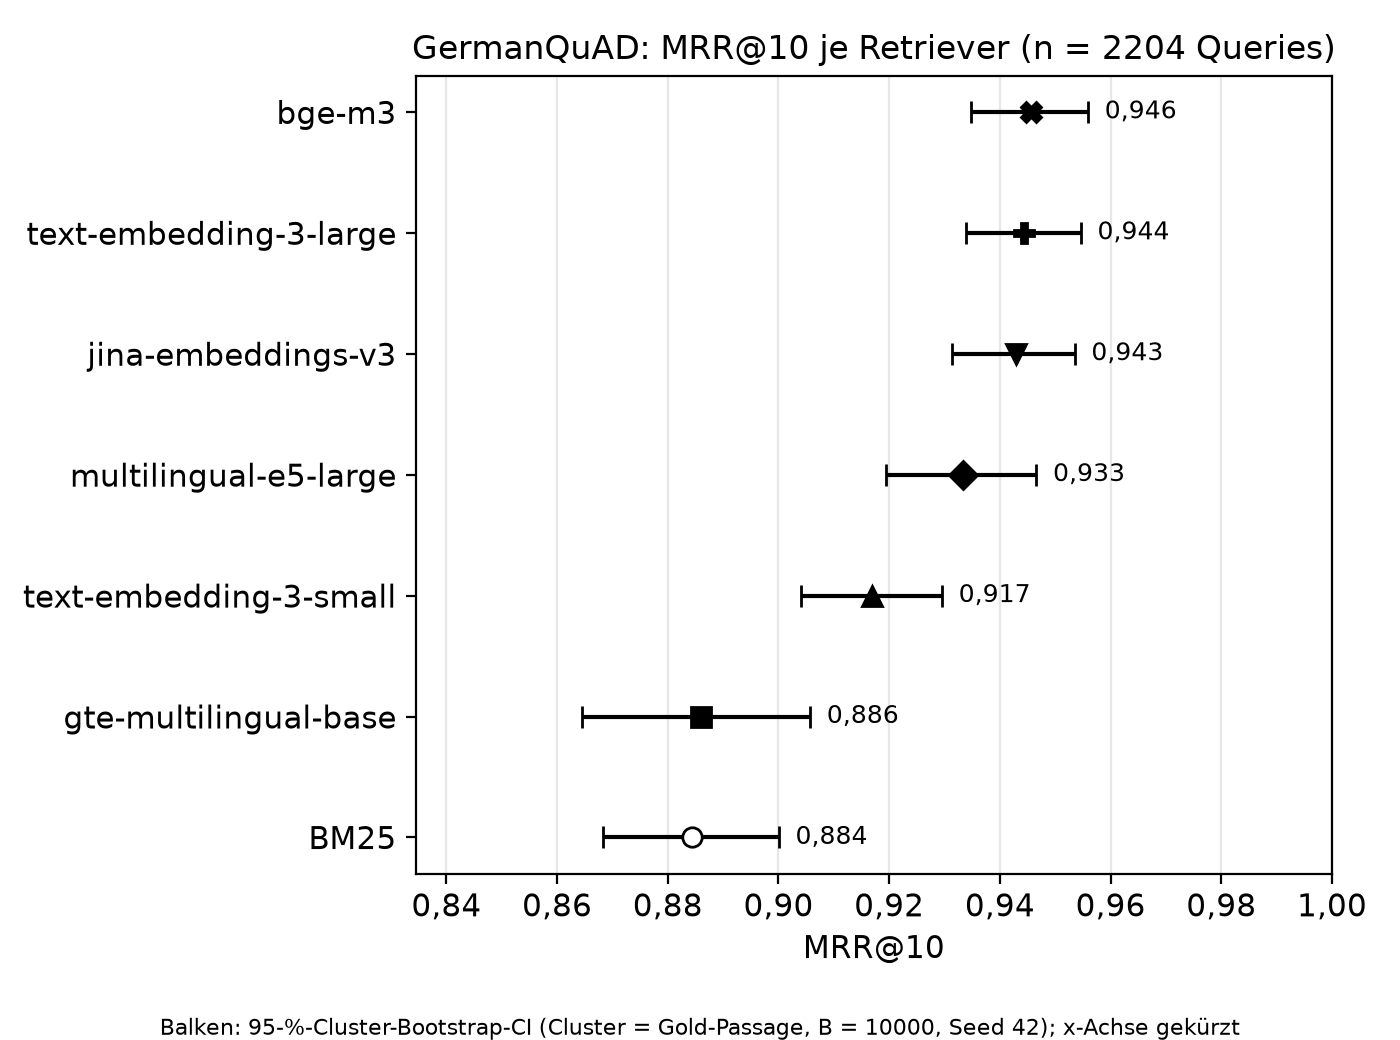

In [8]:
display(Image(filename=str(HARNESS / "results" / "fig_mrr10_ci.png")))

## Schritt 3: Konsistenzprüfung
Die im Notebook aus den Per-Query-Rängen berechneten Kennzahlen werden gegen `comparison_germanquad.json` und die `metrics_germanquad.json` der Modelle geprüft: Mittelwerte, Differenzen, n≠0, Holm-Korrektur, Modellmetriken und Deckeneffekt-Flag. Die Tests (p, CI) werden nicht neu simuliert; ihre Neuberechnung leistet `compare_models.py`.

In [9]:
from significance import make_clusters, cluster_sums
cinv, ncl, sizes = make_clusters(clusters)
assert CMP["n_queries"] == len(qids) and CMP["n_clusters"] == ncl == 474
fn = {**cm.METRICS}
for t in CMP["tests"]:
    f, ra, rb = fn[t["metric"]], RANKS[t["a"]], RANKS[t["b"]]
    da, db = f(ra), f(rb)
    assert abs(da.mean() - t["mean_a"]) < 1e-9 and abs(db.mean() - t["mean_b"]) < 1e-9, t
    assert abs((db - da).mean() - t["diff_b_minus_a"]) < 1e-9, t
    nz = int((np.abs(cluster_sums(db - da, cinv, ncl)) > 1e-12).sum())
    assert nz == t["n_nonzero_clusters"], (t["a"], t["b"], t["metric"], nz)
    assert t["not_informative"] == (nz < CMP["meta"]["threshold_not_informative"]) or "mcnemar_b_plus_c" in t
# Holm je Familie neu berechnen
for fam, g in TESTS.groupby("family"):
    size = 6 if fam.startswith("confirmatory") else None
    assert np.allclose(holm(g.p_cluster_signflip.tolist(), size), g.p_holm.to_numpy()), fam
# Modellmetriken gegen Per-Query-Ränge
for m, d in NATIVE.items():
    v = metrics_of(RANKS[m]); mm = {x["k"]: x for x in d["metrics"]}
    assert abs(mm[10]["mrr_at_k"] - v["MRR@10"]) < 1e-9 and abs(mm[1]["success_at_k"] - v["Success@1"]) < 1e-9, m
    assert abs(mm[5]["success_at_k"] - v["Success@5"]) < 1e-9 and abs(mm[10]["success_at_k"] - v["Success@10"]) < 1e-9, m
for m, d in S512.items():
    assert abs({x["k"]: x for x in d["metrics"]}[10]["mrr_at_k"] - metrics_of(R512[m])["MRR@10"]) < 1e-9, m
assert len(conf) == 6 and (conf.a == "bm25").all()
print(f"Konsistenzprüfung bestanden: {len(TESTS)} Tests, 6 konfirmatorisch, {len(NATIVE)} Modelle, {len(S512)} 512-Läufe.")

Konsistenzprüfung bestanden: 39 Tests, 6 konfirmatorisch, 6 Modelle, 3 512-Läufe.


## Schritt 4: Umgebung und Provenienz

In [10]:
rows = []
for m, d in NATIVE.items():
    e, env = d["experiment"], d["environment"]
    api = e.get("openai_api", {})
    rows.append({"Modell": e["model_name"], "Revision / API-Modell": e.get("model_revision") or api.get("returned_models", ["?"])[0],
                 "Remote-Code-Revision": e.get("code_revision_loaded", ""), "max_seq_length effektiv": e.get("max_seq_length_effective", "API"),
                 "Präfixe/Tasks": (e["query_prefix"] + "|" + e["doc_prefix"]) if e["query_prefix"] else (f'{e["query_task"]}|{e["doc_task"]}' if e.get("query_task") else "-"),
                 "Zeitstempel (UTC)": env["timestamp_utc"][:19], "Encodierung (s)": env["encode_seconds"]})
display(pd.DataFrame(rows).style.hide(axis="index"))
e0, en0 = NATIVE["e5-large"]["experiment"], NATIVE["e5-large"]["environment"]
print("Stack:", {k: e0[k] for k in ("python", "sentence_transformers", "torch", "transformers", "device")},
      "numpy", en0["numpy"], "| Hardware:", en0["platform"], f'{en0["cpu_count"]} CPU-Kerne')
api = NATIVE["openai-3-large"]["experiment"]["openai_api"]
print("OpenAI-Paket:", NATIVE["openai-3-large"]["experiment"]["openai"], "| Abruf 3-large:", api["first_request_utc"][:19], "bis", api["last_request_utc"][:19])
m = CMP["meta"]
print(f'Vergleich: Seed {m["seed"]}, B_perm {m["B_permutation"]}, B_boot {m["B_bootstrap"]}, exakt bei n≠0 <= {m["exact_if_n_nonzero_le"]}, '
      f'Schwelle {m["threshold_not_informative"]}, numpy {m["numpy"]}, Zeitstempel {m["timestamp_utc"][:19]} UTC')
tl = json.loads((HARNESS / "token_lengths.json").read_text())
print("Passagen > 512 Tokens:", {k: v["n_over_512"] for k, v in tl["models"].items()})

Modell,Revision / API-Modell,Remote-Code-Revision,max_seq_length effektiv,Präfixe/Tasks,Zeitstempel (UTC),Encodierung (s)
intfloat/multilingual-e5-large,3d7cfbdacd47fdda877c5cd8a79fbcc4f2a574f3,,512,query: |passage:,2026-09-30T05:35:46,464.600000
BAAI/bge-m3,5617a9f61b028005a4858fdac845db406aefb181,,8192,-,2026-09-30T04:22:10,766.200000
Alibaba-NLP/gte-multilingual-base,9bbca17d9273fd0d03d5725c7a4b0f6b45142062,40ced75c3017eb27626c9d4ea981bde21a2662f4,8192,-,2026-09-30T04:09:21,317.000000
jinaai/jina-embeddings-v3,ab036b023d30b4d1138c4c3bfa9f0c445ab455d6,bd55a5ec8e6c0fb1d6c26efb4b6a4a74ce8a88d3,8194,retrieval.query|retrieval.passage,2026-09-30T04:51:23,1751.000000
text-embedding-3-small,text-embedding-3-small,,API,-,2026-09-30T04:04:27,21.300000
text-embedding-3-large,text-embedding-3-large,,API,-,2026-09-30T04:04:52,25.100000


Stack: {'python': '3.11.15', 'sentence_transformers': '5.7.0', 'torch': '2.14.0+cpu', 'transformers': '4.57.3', 'device': 'cpu'} numpy 2.4.6 | Hardware: Linux-6.18.44-fc-v50-x86_64-with-glibc2.39 4 CPU-Kerne
OpenAI-Paket: 3.22.1 | Abruf 3-large: 2026-09-30T04:04:28 bis 2026-09-30T04:04:52
Vergleich: Seed 42, B_perm 100000, B_boot 10000, exakt bei n≠0 <= 16, Schwelle 20, numpy 2.4.6, Zeitstempel 2026-09-30T05:36:29 UTC
Passagen > 512 Tokens: {'e5-large': 144, 'bge-m3': 143, 'gte-multilingual-base': 143, 'jina-v3': 143}


## Zusammenfassung
Rohbefunde aus den persistierten Läufen (native Eingabelänge, GermanQuAD-Test, MRR@10, Seed 42): siehe Tabelle 2 und 3. Fünf von sechs Embeddern liegen signifikant über BM25 (Holm-korrigiert, Cluster-Sign-Flip); gte-multilingual-base ist von BM25 nicht unterscheidbar. Kein konfirmatorischer Vergleich unterschreitet die Deckeneffekt-Schwelle n≠0 = 20. Die Paarvergleiche und die 512-Sensitivität sind explorativ. Die Konsistenzprüfung bestätigt, dass alle Kennzahlen aus den Per-Query-Rängen mit `comparison_germanquad.json` übereinstimmen. Grenzen: ein Datensatz (474 Passagen, je Frage genau eine relevante Passage), Deckeneffekte im oberen MRR-Bereich, CPU-Läufe ohne Wiederholung (Encodierung ist deterministisch bis auf Hardware-Rundung).